# 3. Height-difference correlations 

In [1]:
import numpy as np
import pandas as pd
import os

from surface_functions import compute_heightdifference_correlations

## Dataframe computations

In [3]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Simulations/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        heightheight_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            heightheight = np.asarray(compute_heightdifference_correlations(phases), dtype=float)

            heightheight_list.append(heightheight)

        # Avoid chained-assignment issues
        df = df.copy()
        df["heightheight"] = heightheight_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE HEIGHT-HEIGHT CORRELATION PER (K, L, T) ##
        # group by K, L, T and compute mean height-height correlation for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            heightheight_arrays = [np.asarray(r, dtype=float) for r in group["heightheight"]]
            mean_heightheight = np.mean(np.stack(heightheight_arrays, axis=0), axis=0)
            
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_heightheight": mean_heightheight,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [4]:
avg_df_path = "Simulations/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_heightheight"] = new_avg["mean_heightheight"]

avg_df.to_pickle(avg_df_path)

In [5]:
avg_df

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2,mean_heightheight
avg_id,,,,,,,,,,,
TimeDep_delta0_L250_K0.01_T20000_M500,TimeDep,0.000000,0,0.01,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.09916611074910535, 0.12446928020870274...","[0.0, 0.09926446968727078, 0.12458840997396499...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L125_K1.0_T20000_M2563,TimeDep,0.000000,0,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",2563,20000,"[0.0, 0.06168110958657668, 0.06939519822266577...","[0.0, 0.061875751647655915, 0.0696491476573002...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L250_K1.0_T20000_M2038,TimeDep,0.000000,0,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",2038,20000,"[0.0, 0.061965631959170625, 0.0700407179442727...","[0.0, 0.062059291870438106, 0.0701756752784753...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L500_K1.0_T20000_M1795,TimeDep,0.000000,0,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1795,20000,"[0.0, 0.0621714227145654, 0.07011549882291095,...","[0.0, 0.06221984053743999, 0.07018256920069725...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L1000_K1.0_T20000_M3448,TimeDep,0.000000,0,1.00,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3448,20000,"[0.0, 0.06239254779952913, 0.07052040800441967...","[0.0, 0.0624165838743001, 0.07055298550407245,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L250_K0.01_T20000_M500,TimeDep,1.373401,atan5,0.01,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.10017369796474682, 0.12628080395076277...","[0.0, 0.10027197517138416, 0.12640602800694029...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L125_K1.0_T20000_M2573,TimeDep,1.373401,atan5,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",2573,20000,"[0.0, 0.08494848921438407, 0.09996033569969529...","[0.0, 0.08513315588534826, 0.10019966225840135...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L250_K1.0_T20000_M2084,TimeDep,1.373401,atan5,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",2084,20000,"[0.0, 0.0853817935442105, 0.10083697526055763,...","[0.0, 0.0854676581318955, 0.1009525728111536, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L500_K1.0_T20000_M1738,TimeDep,1.373401,atan5,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1738,20000,"[0.0, 0.08563020075369611, 0.10095360330656193...","[0.0, 0.08567629915216575, 0.10101165939873313...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


## Inspection of the computed quantities

In [2]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

%load_ext autoreload
%autoreload 2

from plotting_helpers_evolution import plot_heightdifference_evolution
from plotting_helpers_collapse import plot_heightdifference_collapse

In [3]:
avg_df_path = "Simulations/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

L = 1000
T = 20000
Ks = [1, 40]

In [4]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": 1/100, "KPZ": 1/10}, "Columnar": {"EW": 1/1500, "KPZ": 1/80}}

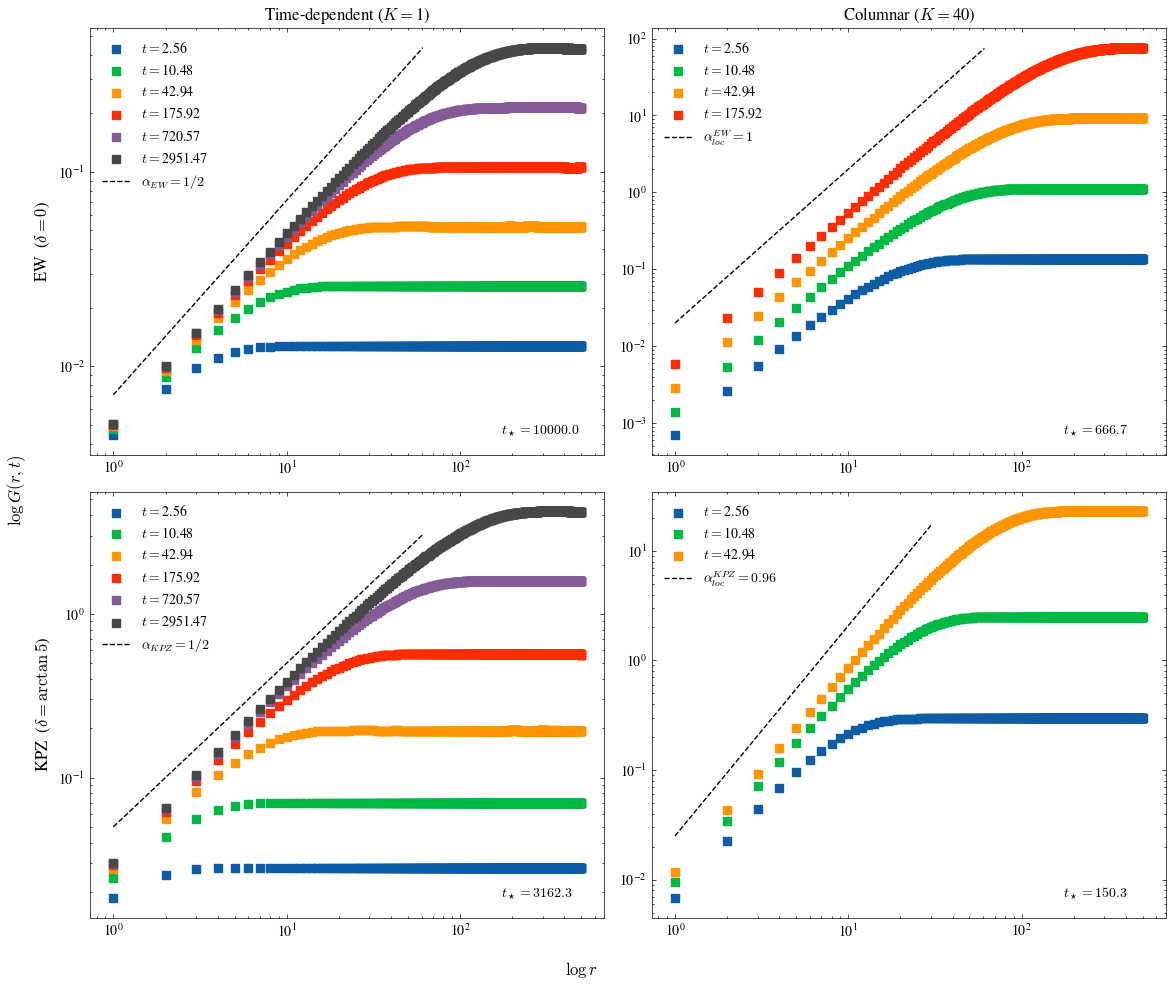

In [12]:
plot_heightdifference_evolution(avg_df, L, T, tx, Ks=Ks)

### Family-Vicsek collapse of the height-height correlations

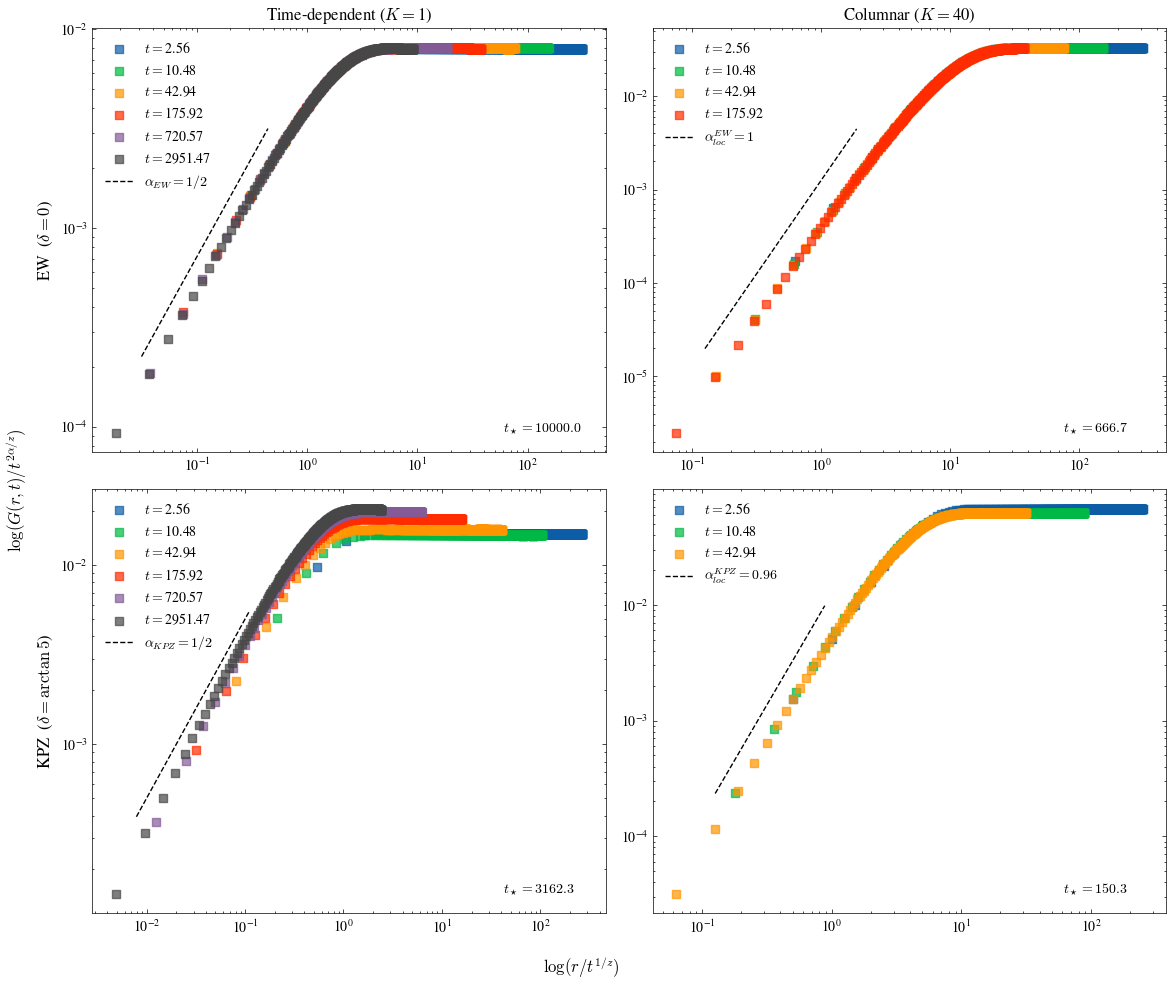

In [13]:
plot_heightdifference_collapse(avg_df, L, T, tx, Ks=Ks)

### Simplest case (temporal noise, EW) collapse visualization

In [14]:
typenoise = "TimeDep"
deltaname = "0"

L = 500

z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.4}}  # anomalous scaling, only for columnar noise
alpha_loc_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 1, "KPZ": 0.96}} # anomalous scaling, only for columnar noise
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": alpha_dict["Columnar"]["EW"]/z_dict["Columnar"]["EW"], "KPZ": alpha_dict["Columnar"]["KPZ"]/z_dict["Columnar"]["KPZ"]}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

markerdict = {125: "^", 250: "x", 500: "o", 1000: "s"}

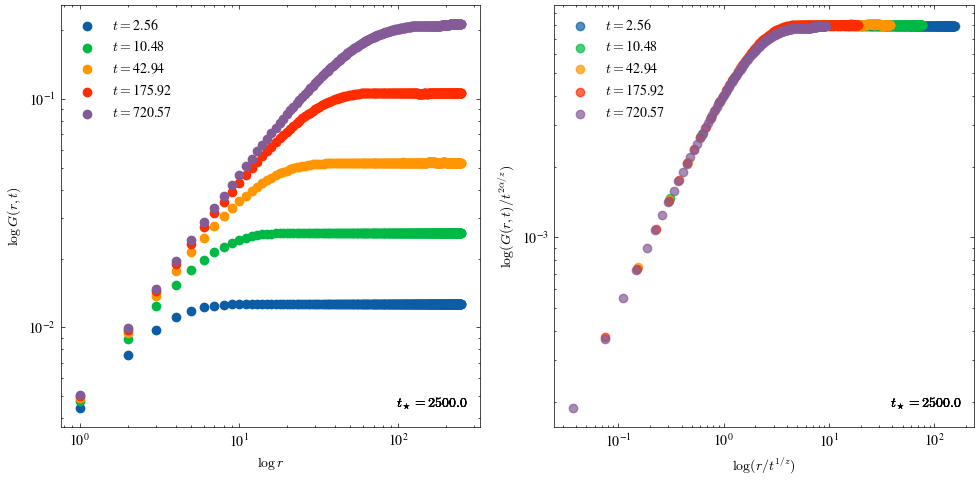

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].set_xlabel(r"$\log r$")
ax[0].set_ylabel(r"$\log G(r,t)$")
ax[1].set_xlabel(r"$\log (r/ t^{1/z})$")
ax[1].set_ylabel(r"$\log (G(r,t)/ t^{2\alpha/z})$")

mask = (
    (avg_df["typenoise"] == typenoise)
    & (avg_df["L"] == L)
    & (avg_df["T"] == T)
    & (avg_df["deltaname"] == deltaname)
    & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
)
sub = avg_df[mask]

for _, row in sub.iterrows():
    t = row["t"]            
    mean_heightheight = row["mean_heightheight"]
    L = row["L"]
    K = row["K"]

    # Exponents
    z = z_dict[typenoise][delta_to_label[deltaname]]
    alpha = alpha_dict[typenoise][delta_to_label[deltaname]]

    t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])

    for ti in range(len(t))[::3]:

        if t[ti] > 0 and t[ti] < t_cross:

            rlen = mean_heightheight.shape[1] # we plot up to half of this since the system is periodic
            rrange = np.array(range(rlen))
            ax[0].scatter(rrange[:int(rlen/2)], mean_heightheight[ti,:int(rlen/2)], label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L])
            ax[0].text(0.8, 0.05, fr'$t_\star={np.round(t_cross,1)}$', fontsize=10, transform=ax[0].transAxes)

            # Collapse variables
            rt1z = rrange[:int(rlen/2)] / t[ti]**(1/z)
            Gt2az = mean_heightheight[ti,:int(rlen/2)] / t[ti]**(2*alpha/z)

            ax[1].scatter(rt1z, Gt2az, label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L], alpha=0.7)
            ax[1].text(0.8, 0.05, fr'$t_\star={np.round(t_cross,1)}$', fontsize=10, transform=ax[1].transAxes)

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.savefig(f"Figures/heighdifference_example.png", dpi=300)
plt.show()
